# 01 — Module A: Loan Default Classification
Compare 8 classifiers on predicting loan default.

In [1]:
import sys, os

# Add project root to path
PROJECT_ROOT = "/Users/nando/PycharmProjects/PythonProject/SmartLender"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.data.loader import load_raw_data, split_data
from src.data.preprocessor import build_preprocessor, get_catboost_cat_indices
from src.models.registry import get_classifiers
from src.models.trainer import run_arena
from src.evaluation.metrics import classification_metrics
from src.evaluation.comparison import save_comparison
from src.evaluation.explainer import get_shap_values, plot_global_importance
from src.config import *

%matplotlib inline
mlflow.set_experiment('SmartLend')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Experiment: artifact_location='/Users/nando/PycharmProjects/PythonProject/SmartLender/mlruns/1', creation_time=1774130745454, experiment_id='1', last_update_time=1774130745454, lifecycle_stage='active', name='SmartLend', tags={}, workspace='default'>

## Load and Split Data

In [2]:
df = load_raw_data(sample_size=200000)
X_train, X_test, y_train, y_test = split_data(df, TARGET_CLASSIFICATION)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Default rate: {y_train.mean():.3f}")

Train: (160000, 21), Test: (40000, 21)
Default rate: 0.199


## Build Preprocessor

In [3]:
preprocessor = build_preprocessor(X_train)
cat_indices = get_catboost_cat_indices(X_train)
print(f"Categorical feature indices for CatBoost: {cat_indices}")

Categorical feature indices for CatBoost: [11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


## Run the Arena — All 8 Classifiers

In [4]:
classifiers = get_classifiers()
comparison_df, results = run_arena(
    models=classifiers,
    preprocessor=preprocessor,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    metrics_fn=classification_metrics,
    cat_feature_indices=cat_indices,
    module_name='module_a',
)

# Sort by AUC-ROC
comparison_df = comparison_df.sort_values('auc_roc', ascending=False)
print(comparison_df.to_string(index=False))

Training Logistic Regression...
  Done: accuracy=0.8044, f1=0.1115, precision=0.5689, recall=0.0618, auc_roc=0.7109, log_loss=0.4533, train_time_s=2.3210, infer_time_s=0.1189
Training Decision Tree...
  Done: accuracy=0.7980, f1=0.1375, precision=0.4519, recall=0.0811, auc_roc=0.6916, log_loss=0.5607, train_time_s=1.9190, infer_time_s=0.1026
Training Random Forest...
  Done: accuracy=0.8037, f1=0.1150, precision=0.5514, recall=0.0642, auc_roc=0.6988, log_loss=0.4583, train_time_s=10.8530, infer_time_s=0.8715
Training Gradient Boosting...
  Done: accuracy=0.8047, f1=0.1276, precision=0.5665, recall=0.0719, auc_roc=0.7140, log_loss=0.4512, train_time_s=132.2330, infer_time_s=0.3328
Training AdaBoost...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


  Done: accuracy=0.8042, f1=0.0904, precision=0.5850, recall=0.0490, auc_roc=0.7084, log_loss=0.5637, train_time_s=50.7330, infer_time_s=1.2073
Training XGBoost...
  Done: accuracy=0.8002, f1=0.1741, precision=0.4867, recall=0.1060, auc_roc=0.7002, log_loss=0.4603, train_time_s=2.0770, infer_time_s=0.1191
Training LightGBM...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Done: accuracy=0.8050, f1=0.1389, precision=0.5656, recall=0.0792, auc_roc=0.7139, log_loss=0.4509, train_time_s=1.9890, infer_time_s=0.2194
Training CatBoost...
  Done: accuracy=0.8045, f1=0.1620, precision=0.5451, recall=0.0952, auc_roc=0.7131, log_loss=0.4519, train_time_s=9.6960, infer_time_s=0.1091
          algorithm  accuracy       f1  precision   recall  auc_roc  log_loss  train_time_s  infer_time_s
  Gradient Boosting  0.804725 0.127555   0.566468 0.071869 0.714046  0.451180       132.233        0.3328
           LightGBM  0.805025 0.138898   0.565647 0.079169 0.713932  0.450935         1.989        0.2194
           CatBoost  0.804500 0.162023   0.545061 0.095154 0.713117  0.451878         9.696        0.1091
Logistic Regression  0.804350 0.111490   0.568946 0.061800 0.710938  0.453268         2.321        0.1189
           AdaBoost  0.804200 0.090360   0.584962 0.048962 0.708415  0.563656        50.733        1.2073
            XGBoost  0.800225 0.174057   0.486705 0.10597

## Save Comparison

In [5]:
save_comparison(comparison_df, 'module_a')

Saved comparison table to /Users/nando/PycharmProjects/PythonProject/SmartLender/results/comparison_tables/module_a.csv


'/Users/nando/PycharmProjects/PythonProject/SmartLender/results/comparison_tables/module_a.csv'

## Confusion Matrices

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


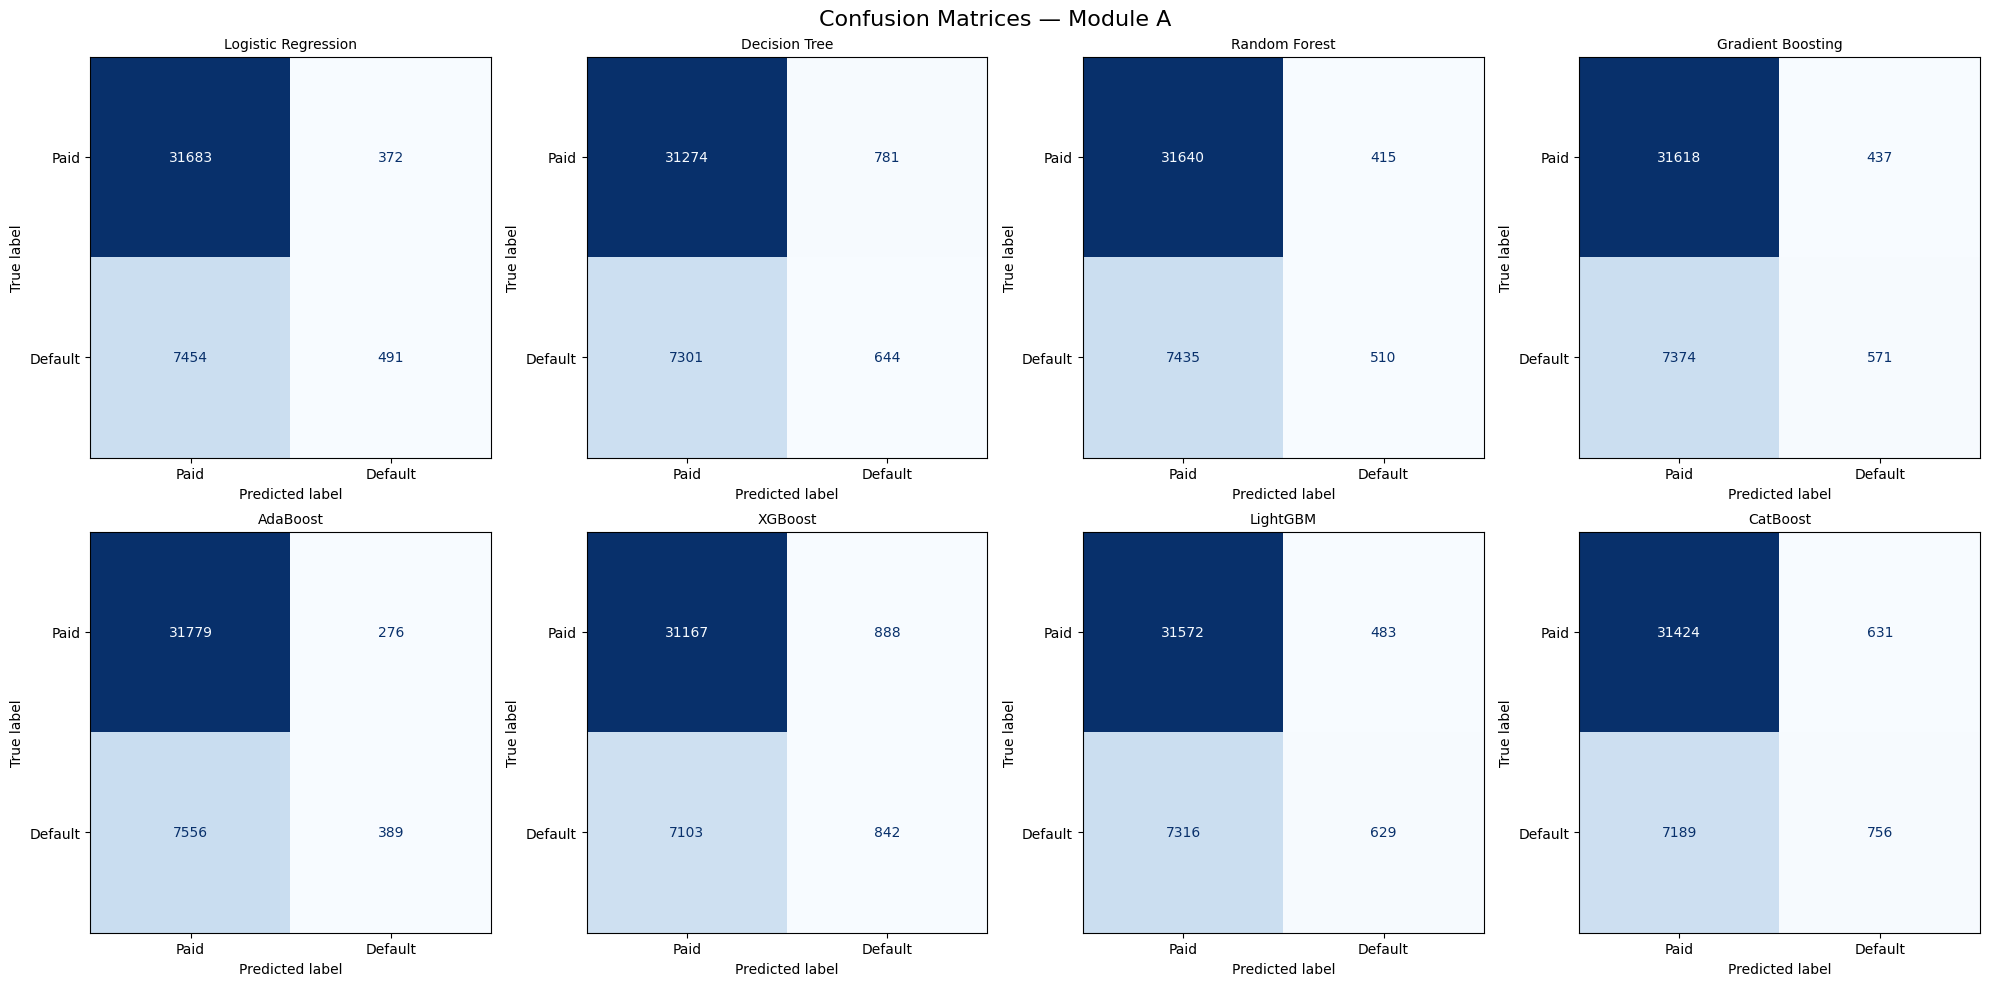

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, result in enumerate(results):
    model = result['model']
    name = result['algorithm']
    if 'CatBoost' in name:
        X_test_pred = X_test.copy()
        for col in X_test_pred.select_dtypes(include=['object', 'category']).columns:
            X_test_pred[col] = X_test_pred[col].fillna('Missing').astype(str)
        y_pred = model.predict(X_test_pred)
    else:
        y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Paid', 'Default'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(name, fontsize=10)
plt.suptitle('Confusion Matrices — Module A', fontsize=16)
plt.tight_layout()
plt.savefig('results/figures/module_a_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## Hyperparameter Tuning (Top 3)

In [7]:
from src.models.tuner import tune_xgboost_classifier, tune_lightgbm_classifier, tune_catboost_classifier

# Prepare preprocessed data for tuning (XGBoost and LightGBM need preprocessed input)
X_train_processed = preprocessor.fit_transform(X_train)

print("Tuning XGBoost...")
xgb_params, xgb_score = tune_xgboost_classifier(X_train_processed, y_train, n_trials=20)
print(f"Best AUC-ROC: {xgb_score:.4f}")
print(f"Best params: {xgb_params}")

print("\nTuning LightGBM...")
lgbm_params, lgbm_score = tune_lightgbm_classifier(X_train_processed, y_train, n_trials=20)
print(f"Best AUC-ROC: {lgbm_score:.4f}")
print(f"Best params: {lgbm_params}")

print("\nTuning CatBoost...")
X_train_cb = X_train.copy()
for col in X_train_cb.select_dtypes(include=['object', 'category']).columns:
    X_train_cb[col] = X_train_cb[col].fillna('Missing').astype(str)
cb_params, cb_score = tune_catboost_classifier(X_train_cb, y_train, cat_indices, n_trials=20)
print(f"Best AUC-ROC: {cb_score:.4f}")
print(f"Best params: {cb_params}")

Tuning XGBoost...


Best trial: 8. Best value: 0.7159: 100%|██████████| 20/20 [02:05<00:00,  6.30s/it] 


Best AUC-ROC: 0.7159
Best params: {'n_estimators': 337, 'max_depth': 4, 'learning_rate': 0.05881768543590188, 'subsample': 0.69974877904086, 'colsample_bytree': 0.6271615846316082, 'min_child_weight': 3, 'reg_alpha': 6.322361300849175, 'reg_lambda': 6.993977119721286e-05}

Tuning LightGBM...


  0%|          | 0/20 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 0. Best value: 0.707976:   5%|▌         | 1/20 [00:12<03:54, 12.33s/it]/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fi

Best AUC-ROC: 0.7150
Best params: {'n_estimators': 369, 'max_depth': 3, 'learning_rate': 0.09285369482451697, 'num_leaves': 43, 'subsample': 0.7712459638757866, 'colsample_bytree': 0.8389419486204706, 'min_child_samples': 5, 'reg_alpha': 2.6737436128158204e-06, 'reg_lambda': 3.039608381629415e-05}

Tuning CatBoost...


Best trial: 15. Best value: 0.716422: 100%|██████████| 20/20 [11:04<00:00, 33.22s/it]

Best AUC-ROC: 0.7164
Best params: {'iterations': 321, 'depth': 6, 'learning_rate': 0.04655688646957869, 'l2_leaf_reg': 8.945122006730886, 'bagging_temperature': 0.7773816117038418, 'random_strength': 5.966895705402285e-06}


## SHAP Analysis (Top 3 Models)

In [1]:
import importlib
import src.evaluation.explainer
importlib.reload(src.evaluation.explainer)
from src.evaluation.explainer import get_shap_values, plot_global_importance
print("✅ Module reloaded!")


ModuleNotFoundError: No module named 'src'

AssertionError: Feature and SHAP matrices must have the same number of rows!

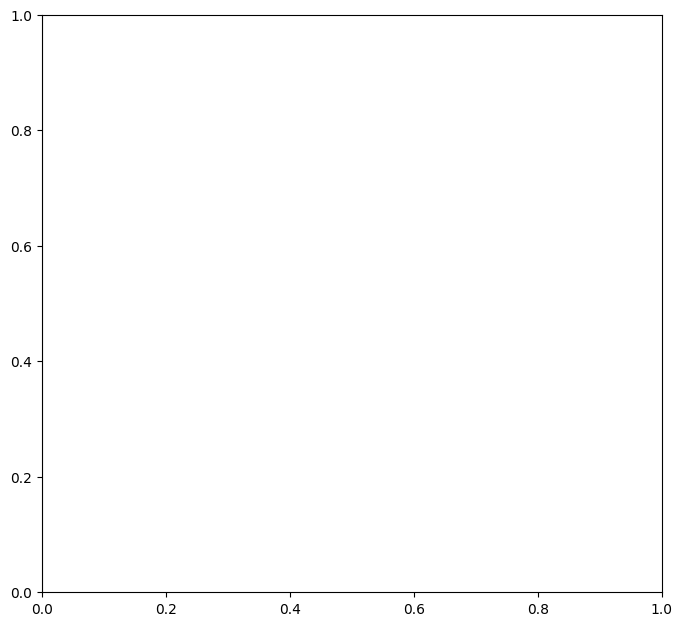

In [9]:
# XGBoost SHAP
xgb_model = [r for r in results if r['algorithm'] == 'XGBoost'][0]['model']
# For pipeline models, we need the preprocessed data and the inner model
X_test_processed = preprocessor.transform(X_test)
feature_names_processed = preprocessor.get_feature_names_out()

xgb_inner = xgb_model.named_steps['model']
explainer, shap_vals = get_shap_values(xgb_inner, X_test_processed)
plot_global_importance(
    shap_vals, X_test_processed, feature_names_processed,
    title='XGBoost — SHAP Feature Importance',
    save_path='results/figures/module_a_shap_xgboost.png'
)